# Experiment v3: Target Encoding

**목표**
- v3 전처리 (Target Encoding + Ordinal + 부분 OHE) 적용
- 기존 v2, v3-a 결과와 비교 (ablation study)
- threshold tuning까지 동일하게 적용

**v3 주요 변경점 (v2 대비)**
- occupation, native_country, workclass → K-Fold Target Encoding
- education → Ordinal Encoding
- marital_status, relationship, race, sex → One-Hot 유지
- Feature shape: 107 → **29** (컴팩트하게 축소)

**비교 기준점**
- v2 + threshold 0.42: 0.8319
- v3-a + threshold 0.44: 0.8323


## 0. 환경 셋업

In [1]:
# category_encoders는 코랩에 기본 설치돼있을 수도 있지만 안전하게 설치
!pip install category_encoders -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


## 1. 데이터 로드

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


train shape: (39073, 15)
test shape: (9769, 14)


## 2. v3 전처리 (Target Encoding + Ordinal + OHE)

In [3]:
# Step 1: Unknown category로 결측 채우기 (v2와 동일)
cat_cols = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country'
]
for col in cat_cols:
    train_df[col] = train_df[col].fillna("Unknown")
    test_df[col] = test_df[col].fillna("Unknown")

# Step 2: target 인코딩
y_train = train_df["income"].map({"<=50K": 0, ">50K": 1})
test_id = test_df["id"]

# feature 분리
X_train = train_df.drop(columns=["income", "id"]).copy()
X_test = test_df.drop(columns=["id"]).copy()

print("결측치 처리 + target 인코딩 완료")


결측치 처리 + target 인코딩 완료


In [4]:
from category_encoders import TargetEncoder
from sklearn.model_selection import KFold

# Step 3: education ordinal encoding (학력 순서 보존)
education_order = {
    'Preschool': 0, '1st-4th': 1, '5th-6th': 2, '7th-8th': 3,
    '9th': 4, '10th': 5, '11th': 6, '12th': 7, 'HS-grad': 8,
    'Some-college': 9, 'Assoc-voc': 10, 'Assoc-acdm': 11,
    'Bachelors': 12, 'Masters': 13, 'Prof-school': 14, 'Doctorate': 15
}

X_train["education_ordinal"] = X_train["education"].map(education_order)
X_test["education_ordinal"] = X_test["education"].map(education_order)
X_train = X_train.drop(columns=["education"])
X_test = X_test.drop(columns=["education"])

# Step 4: Target Encoding 대상 컬럼 원본 보관 (나중에 KFold에 사용)
te_cols = ["occupation", "native_country", "workclass"]
X_train_te_raw = X_train[te_cols].copy()
X_test_te_raw = X_test[te_cols].copy()

# Step 5: 저카디널리티 컬럼은 One-Hot Encoding
ohe_cols = ["marital_status", "relationship", "race", "sex"]
X_train = pd.get_dummies(X_train, columns=ohe_cols)
X_test = pd.get_dummies(X_test, columns=ohe_cols)

# train/test 컬럼 정렬
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("education ordinal + OHE 완료, 다음 단계: Target Encoding")


education ordinal + OHE 완료, 다음 단계: Target Encoding


In [5]:
# Step 6: K-Fold Target Encoding (train) — leakage 방지의 핵심
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# te_cols 초기화 (나중에 fold별로 채울 거)
for col in te_cols:
    X_train[col] = 0.0

# 각 fold마다 나머지 fold로 fit, 자기 fold에 transform 적용
for train_idx, val_idx in kf.split(X_train):
    te = TargetEncoder(cols=te_cols, smoothing=1.0)
    te.fit(X_train_te_raw.iloc[train_idx], y_train.iloc[train_idx])
    X_train.loc[X_train.index[val_idx], te_cols] = te.transform(
        X_train_te_raw.iloc[val_idx]
    ).values

# Step 7: Test set은 전체 train으로 fit한 encoder 사용
te_final = TargetEncoder(cols=te_cols, smoothing=1.0)
te_final.fit(X_train_te_raw, y_train)
X_test[te_cols] = te_final.transform(X_test_te_raw).values

print("X_train shape:", X_train.shape, " (v2: 107 → v3: 29 예상)")
print("X_test shape:", X_test.shape)

# Target encoding 결과 미리보기
print("\nTarget encoded columns 예시:")
print(X_train[te_cols].head())


X_train shape: (39073, 29)  (v2: 107 → v3: 29 예상)
X_test shape: (9769, 29)

Target encoded columns 예시:
   occupation  native_country  workclass
0    0.451735        0.243792   0.218793
1    0.478945        0.244314   0.217008
2    0.037440        0.244063   0.218174
3    0.137430        0.244314   0.217008
4    0.199357        0.242348   0.273083


## 3. Train/Validation Split + 평가 함수

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(model, X_val, y_val, name="model"):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    score = (f1 + auc) / 2
    print(f"[{name}]  F1 = {f1:.4f}  AUC = {auc:.4f}  (F1+AUC)/2 = {score:.4f}")
    return {"name": name, "f1": f1, "auc": auc, "score": score}

print("train:", X_tr.shape, "  val:", X_val.shape)


train: (31258, 29)   val: (7815, 29)


## 4. v3 + XGBoost

In [7]:
from xgboost import XGBClassifier

xgb_v3 = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
)
xgb_v3.fit(X_tr, y_tr)
xgb_v3_result = evaluate(xgb_v3, X_val, y_val, name="XGBoost v3")


[XGBoost v3]  F1 = 0.7110  AUC = 0.9286  (F1+AUC)/2 = 0.8198


In [8]:
# 5-fold CV
xgb_v3_cv_f1 = cross_val_score(xgb_v3, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
xgb_v3_cv_auc = cross_val_score(xgb_v3, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"XGBoost v3 5-fold CV F1 : {xgb_v3_cv_f1.mean():.4f}  (±{xgb_v3_cv_f1.std():.4f})")
print(f"XGBoost v3 5-fold CV AUC: {xgb_v3_cv_auc.mean():.4f}  (±{xgb_v3_cv_auc.std():.4f})")
print(f"XGBoost v3 5-fold CV (F1+AUC)/2: {(xgb_v3_cv_f1.mean() + xgb_v3_cv_auc.mean()) / 2:.4f}")


XGBoost v3 5-fold CV F1 : 0.7067  (±0.0045)
XGBoost v3 5-fold CV AUC: 0.9273  (±0.0033)
XGBoost v3 5-fold CV (F1+AUC)/2: 0.8170


## 5. v3 + LightGBM

In [9]:
from lightgbm import LGBMClassifier

lgbm_v3 = LGBMClassifier(
    n_estimators=200, learning_rate=0.05,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgbm_v3.fit(X_tr, y_tr)
lgbm_v3_result = evaluate(lgbm_v3, X_val, y_val, name="LightGBM v3")


[LightGBM v3]  F1 = 0.7092  AUC = 0.9285  (F1+AUC)/2 = 0.8188


In [10]:
# 5-fold CV
lgbm_v3_cv_f1 = cross_val_score(lgbm_v3, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
lgbm_v3_cv_auc = cross_val_score(lgbm_v3, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"LightGBM v3 5-fold CV F1 : {lgbm_v3_cv_f1.mean():.4f}  (±{lgbm_v3_cv_f1.std():.4f})")
print(f"LightGBM v3 5-fold CV AUC: {lgbm_v3_cv_auc.mean():.4f}  (±{lgbm_v3_cv_auc.std():.4f})")
print(f"LightGBM v3 5-fold CV (F1+AUC)/2: {(lgbm_v3_cv_f1.mean() + lgbm_v3_cv_auc.mean()) / 2:.4f}")


LightGBM v3 5-fold CV F1 : 0.7086  (±0.0033)
LightGBM v3 5-fold CV AUC: 0.9282  (±0.0036)
LightGBM v3 5-fold CV (F1+AUC)/2: 0.8184


## 6. Threshold Tuning

In [17]:
# 더 나은 모델 선택 (5-fold CV 기준)
xgb_v3_cv_avg = (xgb_v3_cv_f1.mean() + xgb_v3_cv_auc.mean()) / 2
lgbm_v3_cv_avg = (lgbm_v3_cv_f1.mean() + lgbm_v3_cv_auc.mean()) / 2

print(f"XGBoost v3 CV 평균: {xgb_v3_cv_avg:.4f}")
print(f"LightGBM v3 CV 평균: {lgbm_v3_cv_avg:.4f}")

if xgb_v3_cv_avg >= lgbm_v3_cv_avg:
    best_model = xgb_v3
    best_model_name = "XGBoost v3"
else:
    best_model = lgbm_v3
    best_model_name = "LightGBM v3"
print(f"\n→ Threshold tuning은 {best_model_name}로 진행")


XGBoost v3 CV 평균: 0.8170
LightGBM v3 CV 평균: 0.8184

→ Threshold tuning은 LightGBM v3로 진행


In [12]:
# Threshold scan
y_val_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores = [f1_score(y_val, (y_val_prob >= t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"기본 threshold (0.5) F1: {f1_score(y_val, (y_val_prob >= 0.5).astype(int)):.4f}")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1: {best_f1:.4f}")


기본 threshold (0.5) F1: 0.7092
Best threshold: 0.41
Best F1: 0.7288


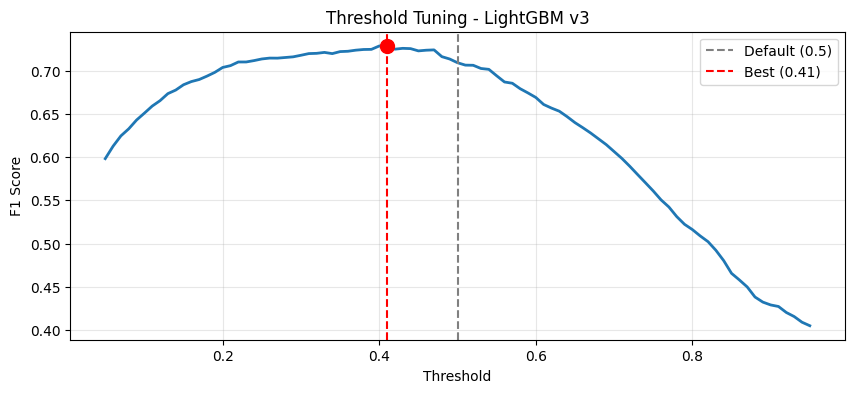

In [13]:
# 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best ({best_threshold:.2f})')
plt.scatter([best_threshold], [best_f1], color='red', s=100, zorder=5)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title(f'Threshold Tuning - {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [14]:
# Best threshold 적용 후 최종 점수
y_val_pred_tuned = (y_val_prob >= best_threshold).astype(int)
f1_tuned = f1_score(y_val, y_val_pred_tuned)
auc_tuned = roc_auc_score(y_val, y_val_prob)
score_tuned = (f1_tuned + auc_tuned) / 2

print(f"[{best_model_name} + Threshold {best_threshold:.2f}]")
print(f"  F1 = {f1_tuned:.4f}")
print(f"  AUC = {auc_tuned:.4f}")
print(f"  (F1+AUC)/2 = {score_tuned:.4f}")


[LightGBM v3 + Threshold 0.41]
  F1 = 0.7288
  AUC = 0.9285
  (F1+AUC)/2 = 0.8286


## 7. 전체 ablation 비교

In [15]:
results_df = pd.DataFrame([
    # 이전 실험 결과
    {"Preprocessing": "v2",   "Feature dim": 107, "Model": "XGBoost",  "Threshold": 0.42, "F1": 0.7342, "AUC": 0.9297, "Avg": 0.8319},
    {"Preprocessing": "v3-a", "Feature dim": 111, "Model": "XGBoost",  "Threshold": 0.44, "F1": 0.7350, "AUC": 0.9297, "Avg": 0.8323},
    # v3 결과 (이번 실험)
    {"Preprocessing": "v3",   "Feature dim": 29, "Model": "XGBoost",  "Threshold": 0.5,  "F1": xgb_v3_result['f1'],  "AUC": xgb_v3_result['auc'],  "Avg": xgb_v3_result['score']},
    {"Preprocessing": "v3",   "Feature dim": 29, "Model": "LightGBM", "Threshold": 0.5,  "F1": lgbm_v3_result['f1'], "AUC": lgbm_v3_result['auc'], "Avg": lgbm_v3_result['score']},
    {"Preprocessing": "v3",   "Feature dim": 29, "Model": best_model_name.replace(" v3",""), "Threshold": round(best_threshold,2), "F1": f1_tuned, "AUC": auc_tuned, "Avg": score_tuned},
])

print(results_df.to_string(index=False))

# v3 효과 평가
prev_best = 0.8323  # v3-a best
v3_best = score_tuned
diff = v3_best - prev_best
print(f"\n이전 best (v3-a, 0.8323) → v3 best ({v3_best:.4f}): {'+' if diff >= 0 else ''}{diff:.4f}")


Preprocessing  Feature dim    Model  Threshold       F1      AUC      Avg
           v2          107  XGBoost       0.42 0.734200 0.929700 0.831900
         v3-a          111  XGBoost       0.44 0.735000 0.929700 0.832300
           v3           29  XGBoost       0.50 0.710958 0.928579 0.819768
           v3           29 LightGBM       0.50 0.709175 0.928453 0.818814
           v3           29 LightGBM       0.41 0.728845 0.928453 0.828649

이전 best (v3-a, 0.8323) → v3 best (0.8286): -0.0037


## 8. prediction.csv 생성 (조건부)

In [16]:
# v3가 이전 best(0.8323)보다 좋을 때만 prediction.csv 업데이트
if score_tuned > 0.8323:
    print(f"v3가 이전 best보다 좋음 ({score_tuned:.4f} > 0.8323) → prediction.csv 업데이트")

    if best_model_name == "XGBoost v3":
        final_model = XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
        )
    else:
        final_model = LGBMClassifier(
            n_estimators=200, learning_rate=0.05,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )

    final_model.fit(X_train, y_train)
    y_test_prob = final_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    prediction = pd.DataFrame({
        "id": test_id.values,
        "y_cls": y_test_pred,
        "y_prob": y_test_prob
    })
    prediction.to_csv("prediction.csv", index=False)
    print(f"prediction.csv saved, {len(prediction)} rows")
    print(f"y_cls 분포: {prediction['y_cls'].value_counts().to_dict()}")
else:
    print(f"v3가 이전 best보다 안 좋음 ({score_tuned:.4f} <= 0.8323) → prediction.csv 유지")


v3가 이전 best보다 안 좋음 (0.8286 <= 0.8323) → prediction.csv 유지
